# Machine Learning models applied with pipelines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score, root_mean_squared_error

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
#df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
"""df = df.sort_values(by="T_0.01_RotD50", ascending=True)
df.reset_index(drop=True, inplace=True)"""
df= pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/CopiaDataBaseSGC.xlsx')

In [3]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)
df.drop(["Topografía"], axis=1, inplace=True)
df.drop(["Geología"], axis=1, inplace=True)

In [4]:
df[df['T_0.01_RotD50'] > 500]


,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Fault Plane (1; 2; X),...,T_2.5_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_7.0_RotD50,T_7.5_RotD50,T_8.0_RotD50,T_9.0_RotD50,T_10.0_RotD50
13,17.0,6.1355,Crustal,8,65,-21,107,71,-153,2,...,39.141536,25.696442,12.860301,7.947506,5.556351,3.865543,3.165451,2.570788,1.677071,1.254188
360,14.7,5.8671,Crustal,196,82,-179,106,89,-8,2,...,34.812816,23.304495,12.370724,7.457155,4.898726,3.445604,2.951366,2.557665,1.977869,1.578374
7855,21.0,7.7822,Interface,27,21,124,171,73,78,1,...,78.765539,42.609423,20.177599,12.372025,8.357405,6.155027,5.360498,4.704366,3.680017,2.952254
7857,30.0,6.8684,Interface,28,21,123,174,73,78,1,...,44.890592,32.192640,15.591689,8.739081,4.918169,3.579181,3.095673,2.721031,2.149639,1.739532


In [5]:
df = df.iloc[:, :df.columns.get_loc("T_0.01_RotD50") + 1]

In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)', 'Style-of-Faulting (S; R; N; U)'], dtype='object')

In [7]:
df = df[df['T_0.01_RotD50'] > 0.001] 
#df = df[df['Rhypo_OpenQuake'] < 350]
#df = df[df['Magnitude'] > 6]

#df["T_0.01_RotD50"]= df["T_0.01_RotD50"]/980
#df = df[df['T_0.01_RotD50'] > 0.0001]
#df["T_0.01_RotD50"]= df["T_0.01_RotD50"]*980
df.reset_index(drop=True, inplace=True)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8805.0,60.022135,62.355457,1.000000,10.000000,20.000000,132.000000,209.900000
Magnitude,8805.0,4.988240,0.676097,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8805.0,177.691766,106.258851,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8805.0,58.318001,23.394911,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8805.0,13.536059,109.974724,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8805.0,169.468938,108.276370,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8805.0,68.292334,16.067991,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8805.0,18.598637,102.788438,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8805.0,1.440091,0.496426,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8805.0,1193.155105,1108.177413,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [9]:
df_copy = df.copy()
X= df_copy.copy()

In [10]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])
df_copy["Rhypo_OpenQuake"]= np.log(df_copy["Rhypo_OpenQuake"])

In [11]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8805.0,60.022135,62.355457,1.000000,10.000000,20.000000,132.000000,209.900000
Magnitude,8805.0,4.988240,0.676097,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8805.0,177.691766,106.258851,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8805.0,58.318001,23.394911,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8805.0,13.536059,109.974724,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8805.0,169.468938,108.276370,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8805.0,68.292334,16.067991,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8805.0,18.598637,102.788438,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8805.0,1.440091,0.496426,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8805.0,1193.155105,1108.177413,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [12]:
Y=X[["T_0.01_RotD50"]].copy()
X.drop(["T_0.01_RotD50"],axis=1, inplace=True)

In [13]:
df_numerico = df_copy.select_dtypes(include=[float, int])

In [14]:
df_copy.drop(["Nodal Plane 1 Rake Angle (deg)"], axis=1, inplace=True)
df_copy.drop(["Nodal Plane 2 Rake Angle (deg)"], axis=1, inplace=True)
df_copy.drop(["Nodal Plane 2 Dip (deg)"], axis=1, inplace=True)
df_copy.drop(["Nodal Plane 2 Strike (deg)"], axis=1, inplace=True)
df_copy.drop(["Rx_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Ry0_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Rjb_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Rrup_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Repi_OpenQuake"], axis=1, inplace=True)
df_copy.drop(["Soil_Class"], axis=1, inplace=True)

In [15]:
# Codificar la variable categórica con OneHotEncoder
X_categorical = df_copy[['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']].astype(str)

enc = OneHotEncoder(sparse_output=False)
X_encoded = enc.fit_transform(X_categorical)  # Devuelve un array listo para KNN

Y_categorical = df_copy[["Fault Plane (1; 2; X)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Y_encoded = enc.fit_transform(Y_categorical)  

Z_categorical = df_copy[["Style-of-Faulting (S; R; N; U)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Z_encoded = enc.fit_transform(Z_categorical)  

"""A_categorical = df_copy[['Soil_Class']].astype(str)

enc = OneHotEncoder(sparse_output=False)
A_encoded = enc.fit_transform(A_categorical)  

B_categorical = df_copy[['Geologia']].astype(str)

enc = OneHotEncoder(sparse_output=False)
B_encoded = enc.fit_transform(B_categorical) """

X_numerical = df_numerico.drop(columns=["T_0.01_RotD50"]).values

# Paso 3: Combinar características numéricas y codificadas
X_final = np.hstack((X_numerical, X_encoded,Y_encoded,Z_encoded,# A_encoded,# B_encoded
                     ))

y = df_copy["T_0.01_RotD50"].values  

In [16]:
"""# Supongamos que y es una serie o array numérico
# Creamos "categorías" artificiales a partir de y
y_binned = pd.qcut(y, q=20, duplicates='drop')  # q=10 -> deciles (puedes ajustar)

# Luego usamos stratify con esta variable discretizada
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.3,
    random_state=0,
    stratify=y_binned
)"""

'# Supongamos que y es una serie o array numérico\n# Creamos "categorías" artificiales a partir de y\ny_binned = pd.qcut(y, q=20, duplicates=\'drop\')  # q=10 -> deciles (puedes ajustar)\n\n# Luego usamos stratify con esta variable discretizada\nX_train, X_test, y_train, y_test = train_test_split(\n    X_final, y,\n    test_size=0.3,\n    random_state=0,\n    stratify=y_binned\n)'

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=0)

## Pipelines

In [18]:
from sklearn.pipeline import Pipeline


### KNN Neighbors

In [19]:
from sklearn.neighbors import KNeighborsRegressor

In [20]:
rmsle_val = []
best_rmsle = 2
for k in range(20):
    k = k+1
    knn = neighbors.KNeighborsRegressor(n_neighbors = k)
    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(root_mean_squared_error(y_test,y_pred))
    if (rmsle < best_rmsle):
        best_rmsle = rmsle
        best_k = k
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ' , k , 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 1.356062621578984
RMSLE value for k=  2 is: 1.275686528410996
RMSLE value for k=  3 is: 1.244609142726575
RMSLE value for k=  4 is: 1.232173712597884
RMSLE value for k=  5 is: 1.231339108357519
RMSLE value for k=  6 is: 1.2291590032379323
RMSLE value for k=  7 is: 1.2326281467719389
RMSLE value for k=  8 is: 1.230544523956408
RMSLE value for k=  9 is: 1.2291914601941865
RMSLE value for k=  10 is: 1.225541643913575
RMSLE value for k=  11 is: 1.224489365529957
RMSLE value for k=  12 is: 1.2248827769035835
RMSLE value for k=  13 is: 1.226821347064913
RMSLE value for k=  14 is: 1.2270531977452885
RMSLE value for k=  15 is: 1.227578411976571
RMSLE value for k=  16 is: 1.226361032369969
RMSLE value for k=  17 is: 1.2268863550503168
RMSLE value for k=  18 is: 1.2275520431601108
RMSLE value for k=  19 is: 1.2276465158483432
RMSLE value for k=  20 is: 1.2269354855827537
Best RMSLE: 1.224489365529957, Best k: 11


In [21]:
pipeKNN = Pipeline([('scaler', MinMaxScaler()),("knn", KNeighborsRegressor(n_neighbors=best_k))])

In [22]:
param_gridknn = {
    'knn__weights': ['uniform', 'distance'],
    #'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [23]:
grid_searchKNN = GridSearchCV(pipeKNN  , param_grid=param_gridknn, scoring='r2', cv=5, n_jobs=6)
grid_searchKNN.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid_searchKNN.best_score_))
print("Test set score: {:.2f}".format(grid_searchKNN.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchKNN.best_params_))

Best cross-validation accuracy: 0.66
Test set score: 0.68
Best parameters: {'knn__metric': 'manhattan', 'knn__weights': 'distance'}


In [24]:
pipeKNNnuevo = Pipeline([('scaler', MinMaxScaler()),
                         ("knn", KNeighborsRegressor(n_neighbors=best_k,
                                                     metric= 'manhattan', weights='uniform'))])

In [25]:
pipeKNNnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn',
                 KNeighborsRegressor(metric='manhattan', n_neighbors=11))])

In [26]:
print("Train score: {:.2f}".format(pipeKNNnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeKNNnuevo.score(X_test, y_test)))

Train score: 0.71
Test score: 0.64


In [27]:
y_pred_knn = pipeKNNnuevo.predict(X_test)
y_pred_knn_todos = pipeKNNnuevo.predict(X_final)

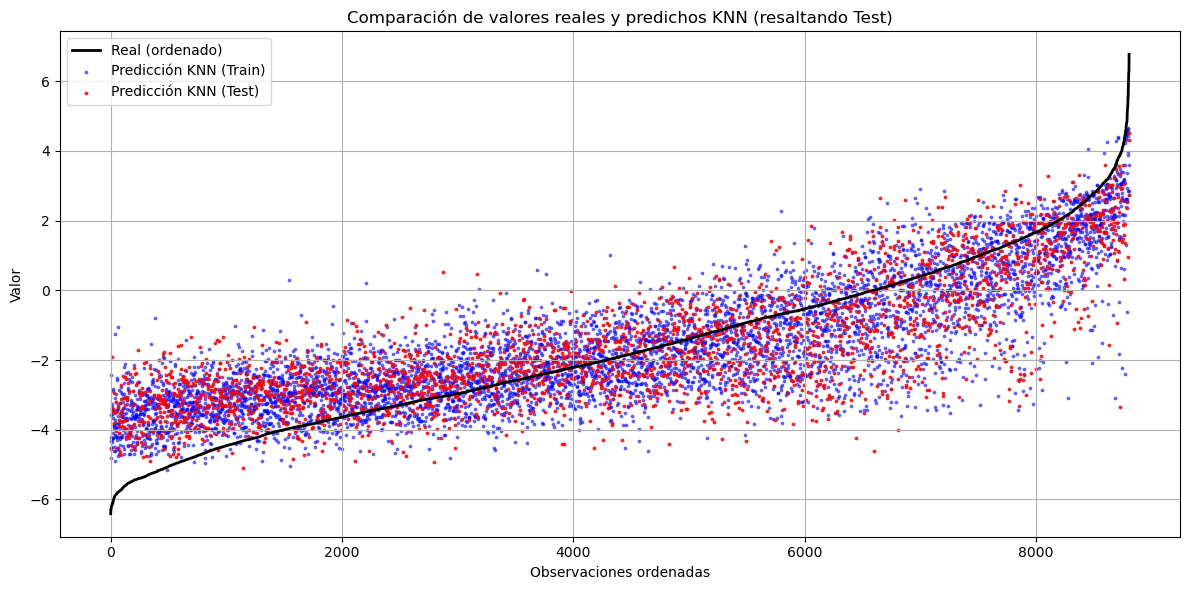

In [28]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_knn_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción KNN (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción KNN (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos KNN (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Regresión Lineal

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
pipeLINEAL= Pipeline([('scaler', MinMaxScaler()), ("reglineal", LinearRegression())])

In [31]:
pipeLINEAL.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('reglineal', LinearRegression())])

In [32]:
print("Train score: {:.2f}".format(pipeLINEAL.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeLINEAL.score(X_test, y_test)))

Train score: 0.66
Test score: 0.64


In [33]:
y_pred_reglineal = pipeLINEAL.predict(X_test)
y_pred_reglineal_todos = pipeLINEAL.predict(X_final)

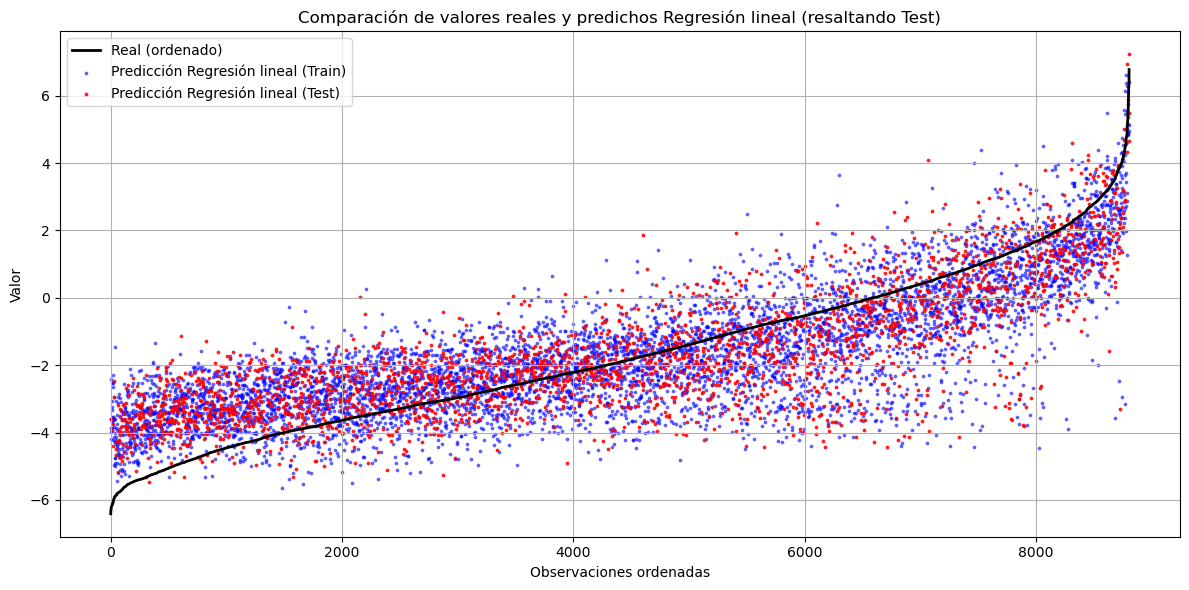

In [34]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_reglineal_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Regresión lineal (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Regresión lineal (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Regresión lineal (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Ridge

In [35]:
from sklearn.linear_model import Ridge

In [36]:
pipeRIDGE= Pipeline([('scaler', MinMaxScaler()), ("ridge", Ridge())])

In [37]:
param_gridridge = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100, 200, 500],  # Regularización
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga'],  # Solvers disponibles
    'ridge__tol': [1e-4, 1e-3, 1e-2],  # Tolerancia para la convergencia
    'ridge__max_iter': [1000, 5000, 10000]  # Iteraciones máximas
}

In [38]:
"""grid_searchRIDGE = GridSearchCV(pipeRIDGE  , param_grid=param_gridridge, scoring='r2', cv=5, n_jobs=-1)
grid_searchRIDGE.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid_searchRIDGE.best_score_))
print("Test set score: {:.2f}".format(grid_searchRIDGE.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchRIDGE.best_params_))"""

'grid_searchRIDGE = GridSearchCV(pipeRIDGE  , param_grid=param_gridridge, scoring=\'r2\', cv=5, n_jobs=-1)\ngrid_searchRIDGE.fit(X_train, y_train)\nprint("Best cross-validation accuracy: {:.2f}".format(grid_searchRIDGE.best_score_))\nprint("Test set score: {:.2f}".format(grid_searchRIDGE.score(X_test, y_test)))\nprint("Best parameters: {}".format(grid_searchRIDGE.best_params_))'

In [39]:
pipeRIDGEnuevo = Pipeline([('scaler', MinMaxScaler()),
                         ("ridge", Ridge(alpha= 0.01, max_iter= 1000, solver= 'auto', tol= 0.0001))])

In [40]:
pipeRIDGEnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('ridge', Ridge(alpha=0.01, max_iter=1000))])

In [41]:
y_pred_Ridge = pipeRIDGEnuevo.predict(X_test)
y_pred_Ridge_todos = pipeRIDGEnuevo.predict(X_final)

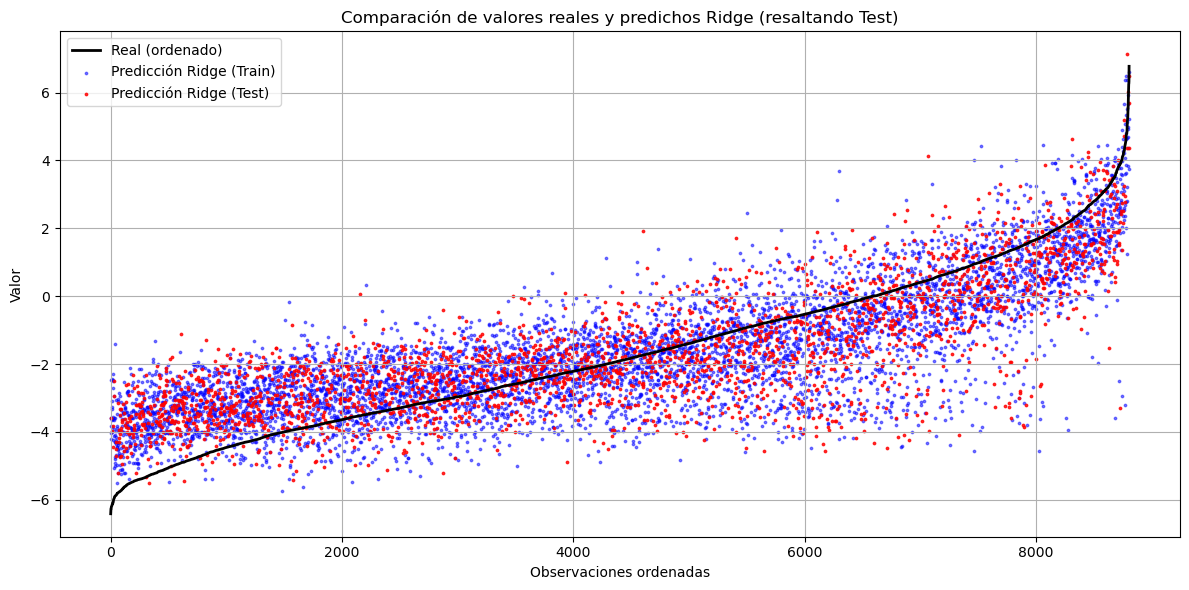

In [42]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_Ridge_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Ridge (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Ridge (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Ridge (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Lasso

In [43]:
from sklearn.linear_model import Lasso

In [44]:
pipeLASSO= Pipeline([('scaler', MinMaxScaler()), ("lasso", Lasso())])

In [45]:
param_gridlasso = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],  # Regularización
    'lasso__max_iter': [1000, 5000, 10000],  # Iteraciones máximas para converger
    'lasso__tol': [1e-4, 1e-3, 1e-2]  # Tolerancia de convergencia
}

In [46]:
"""grid_searchLASSO = GridSearchCV(pipeLASSO  , param_grid=param_gridlasso, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_searchLASSO.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid_searchLASSO.best_score_))
print("Test set score: {:.2f}".format(grid_searchLASSO.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchLASSO.best_params_))"""

'grid_searchLASSO = GridSearchCV(pipeLASSO  , param_grid=param_gridlasso, scoring=\'neg_root_mean_squared_error\', cv=5, n_jobs=-1)\ngrid_searchLASSO.fit(X_train, y_train)\nprint("Best cross-validation accuracy: {:.2f}".format(grid_searchLASSO.best_score_))\nprint("Test set score: {:.2f}".format(grid_searchLASSO.score(X_test, y_test)))\nprint("Best parameters: {}".format(grid_searchLASSO.best_params_))'

In [47]:
pipeLASSOnuevo = Pipeline([('scaler', MinMaxScaler()),
                         ("lasso", Lasso(alpha= 0.0001, max_iter=10000, tol= 0.0001))])

In [48]:
pipeLASSOnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('lasso', Lasso(alpha=0.0001, max_iter=10000))])

In [49]:
y_pred_Lasso = pipeLASSOnuevo.predict(X_test)
y_pred_Lasso_todos = pipeLASSOnuevo.predict(X_final)

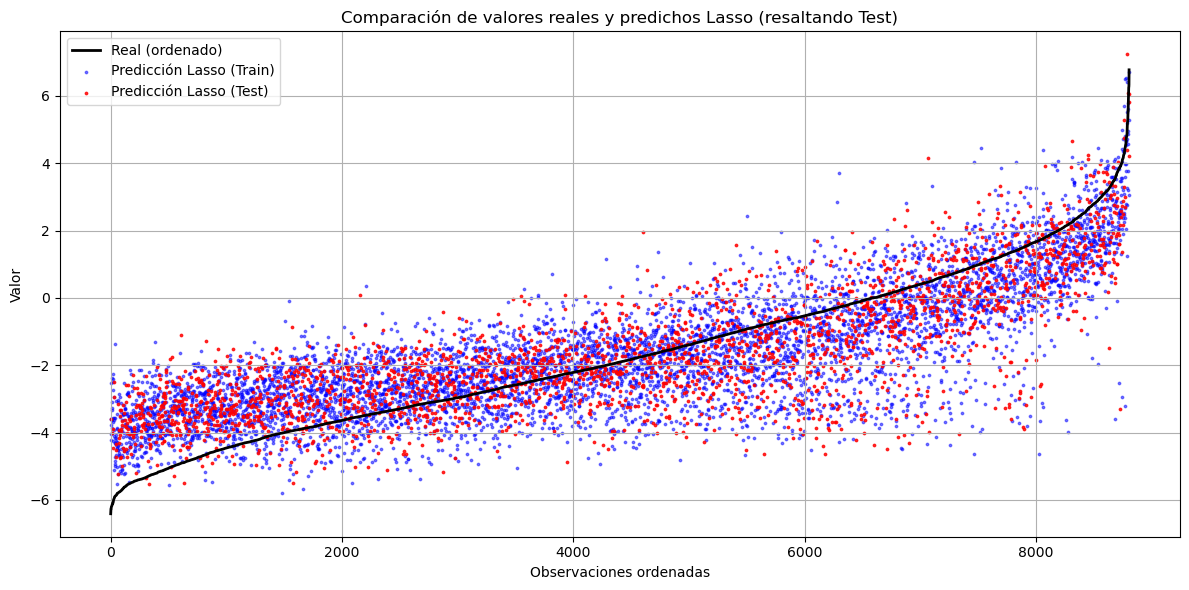

In [50]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_Lasso_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Lasso (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Lasso (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Lasso (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
pipeRF= Pipeline([ ("rf", RandomForestRegressor())])

In [53]:
param_gridRF = {
    'rf__n_estimators': [200,300],
    'rf__max_depth': [10,20,30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
}

In [54]:
"""grid_searchRF = GridSearchCV(pipeRF, param_grid=param_gridRF, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_searchRF.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchRF.best_score_))
print("Test set score: {:.2f}".format(-grid_searchRF.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchRF.best_params_))"""

'grid_searchRF = GridSearchCV(pipeRF, param_grid=param_gridRF, scoring=\'neg_root_mean_squared_error\', cv=5, n_jobs=-1)\ngrid_searchRF.fit(X_train, y_train)\nprint("Best cross-validation accuracy: {:.2f}".format(-grid_searchRF.best_score_))\nprint("Test set score: {:.2f}".format(-grid_searchRF.score(X_test, y_test)))\nprint("Best parameters: {}".format(grid_searchRF.best_params_))'

In [55]:
"""print("Best cross-validation accuracy: 1.09")
print("Test set score: 1.04")
print("Best parameters: {'rf__max_depth': 30, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}")"""

'print("Best cross-validation accuracy: 1.09")\nprint("Test set score: 1.04")\nprint("Best parameters: {\'rf__max_depth\': 30, \'rf__min_samples_leaf\': 1, \'rf__min_samples_split\': 5, \'rf__n_estimators\': 300}")'

In [56]:
"""pipeRFnuevo = Pipeline([('rf', RandomForestRegressor(n_estimators=200,max_depth=20,min_samples_split=2,
                                                     criterion='squared_error',min_samples_leaf =2
                                                     , n_jobs=-1))])"""

"pipeRFnuevo = Pipeline([('rf', RandomForestRegressor(n_estimators=200,max_depth=20,min_samples_split=2,\n                                                     criterion='squared_error',min_samples_leaf =2\n                                                     , n_jobs=-1))])"

In [57]:
pipeRFnuevo = Pipeline([('rf',RandomForestRegressor(n_estimators=500,max_depth=8,min_samples_split=5,
                                                     criterion='squared_error',min_samples_leaf =10
                                                     , n_jobs=-1))])

In [58]:
pipeRFnuevo.fit(X_train, y_train)

Pipeline(steps=[('rf',
                 RandomForestRegressor(max_depth=8, min_samples_leaf=10,
                                       min_samples_split=5, n_estimators=500,
                                       n_jobs=-1))])

In [59]:
print("Train score: {:.2f}".format(pipeRFnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeRFnuevo.score(X_test, y_test)))

Train score: 0.80
Test score: 0.76


In [60]:
y_pred_RAND = pipeRFnuevo.predict(X_test)
y_pred_RAND_todos = pipeRFnuevo.predict(X_final)

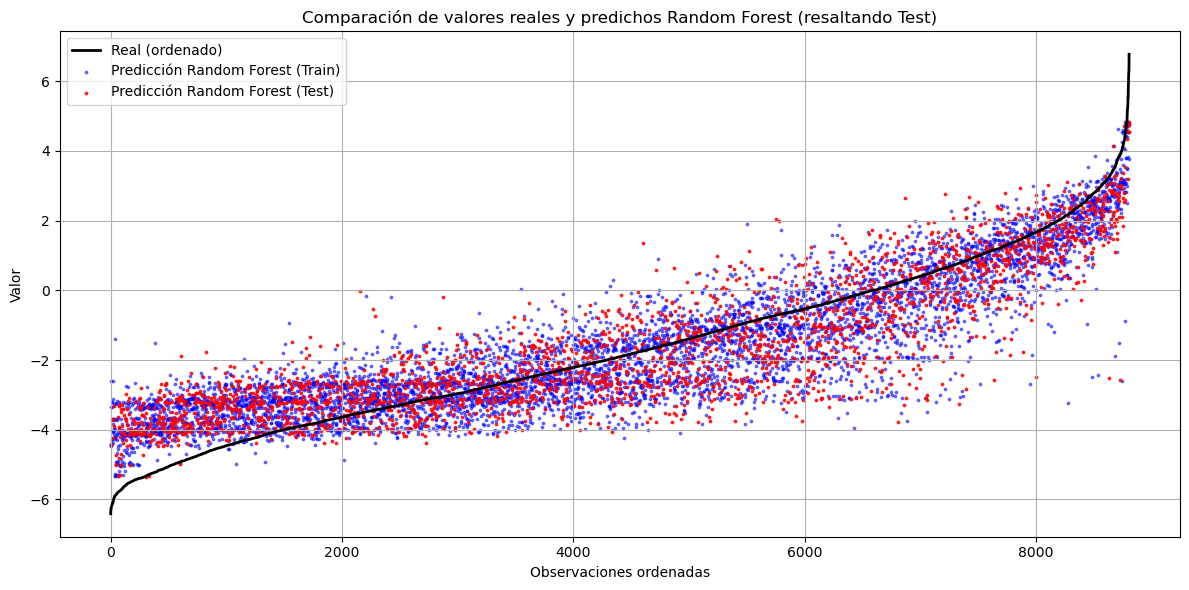

In [61]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_RAND_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Random Forest (Train)', color='blue', s=3, alpha=0.5)
# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Random Forest (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Random Forest (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost

In [62]:
import xgboost as xgb
from xgboost import XGBRegressor
print(xgb.build_info())
print(xgb.__version__)

{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 4], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 3, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\elias\\AppData\\Roaming\\Python\\Python39\\site-packages\\xgboost\\lib\\xgboost.dll'}
2.1.4


In [63]:
pipeXGB= Pipeline([ ("xgb", XGBRegressor(tree_method="gpu_hist", gpu_id=1))])

In [64]:
param_gridXGB = {
    'xgb__max_depth': [5,6],
    'xgb__min_child_weight': [1, 5,10],
    'xgb__subsample': [0.7, 1],
    'xgb__colsample_bytree': [0.7, 1],
    'xgb__learning_rate': [0.1, 0.2],
    'xgb__n_estimators': [100,200],
    'xgb__reg_lambda': [0,1, 10],
    'xgb__reg_alpha': [0,1 ,10]
}

In [65]:
"""grid_searchXGB = GridSearchCV(pipeXGB, param_grid=param_gridXGB, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_searchXGB.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchXGB.best_score_))
print("Test set score: {:.2f}".format(-grid_searchXGB.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchXGB.best_params_))"""

'grid_searchXGB = GridSearchCV(pipeXGB, param_grid=param_gridXGB, scoring=\'neg_root_mean_squared_error\', cv=5, n_jobs=-1)\ngrid_searchXGB.fit(X_train, y_train)\nprint("Best cross-validation accuracy: {:.2f}".format(-grid_searchXGB.best_score_))\nprint("Test set score: {:.2f}".format(-grid_searchXGB.score(X_test, y_test)))\nprint("Best parameters: {}".format(grid_searchXGB.best_params_))'

In [66]:
print("Best cross-validation RMSE: 0.98")
print("Test set score: 0.91")
print("Best parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 1, 'xgb__reg_lambda': 0, 'xgb__subsample': 1}")


Best cross-validation RMSE: 0.98
Test set score: 0.91
Best parameters: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 1, 'xgb__reg_lambda': 0, 'xgb__subsample': 1}


In [67]:
"""pipeXGBnuevo = Pipeline([('xgb', XGBRegressor(colsample_bytree= 0.7,
                            learning_rate= 0.1,
                            max_depth=6,
                            min_child_weight=5,
                            n_estimators= 200,
                            reg_alpha= 1,
                            reg_lambda= 0,
                            subsample= 1))])"""

"pipeXGBnuevo = Pipeline([('xgb', XGBRegressor(colsample_bytree= 0.7,\n                            learning_rate= 0.1,\n                            max_depth=6,\n                            min_child_weight=5,\n                            n_estimators= 200,\n                            reg_alpha= 1,\n                            reg_lambda= 0,\n                            subsample= 1))])"

In [68]:
pipeXGBnuevo = Pipeline([('xgb', XGBRegressor(max_depth=3,n_estimators= 200, reg_alpha= 10,
                            reg_lambda= 0.01,learning_rate= 0.1 ))])

In [69]:
pipeXGBnuevo.fit(X_train, y_train)

Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [70]:
print("Train score: {:.2f}".format(pipeXGBnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeXGBnuevo.score(X_test, y_test)))

Train score: 0.84
Test score: 0.82


In [71]:
y_pred_XGB = pipeXGBnuevo.predict(X_test)
y_pred_XGB_todos = pipeXGBnuevo.predict(X_final)

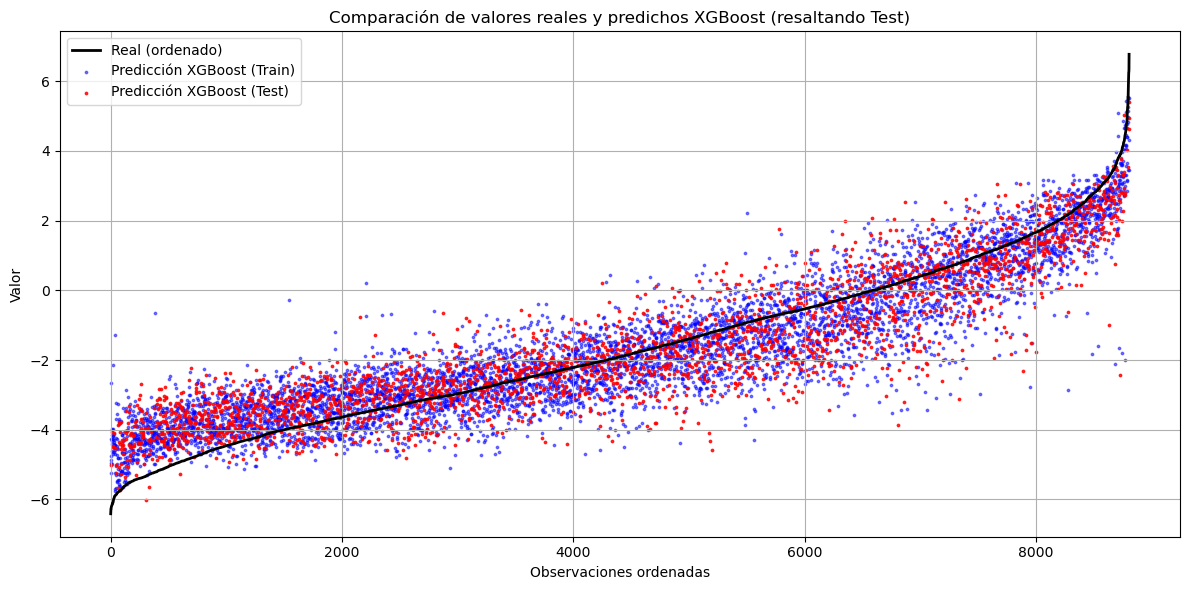

In [72]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_XGB_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción XGBoost (Train)', color='blue', s=3, alpha=0.5)

# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción XGBoost (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos XGBoost (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [73]:
X_XGB=df_copy.copy()

X_XGB[categorical_columns] = X_XGB[categorical_columns].astype('category')

X_XGB.drop(["T_0.01_RotD50"],axis=1, inplace=True)

In [74]:
X_trainXGB, X_testXGB, y_trainXGB, y_testXGB = train_test_split(X_XGB, df_copy["T_0.01_RotD50"], test_size=0.3, random_state=0)
f_importance = XGBRegressor(colsample_bytree= 0.7,learning_rate= 0.1,max_depth=6,min_child_weight=5,n_estimators= 200,reg_alpha= 1,reg_lambda= 0,subsample= 1, enable_categorical=True)
f_importance.fit(X_trainXGB, y_trainXGB)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

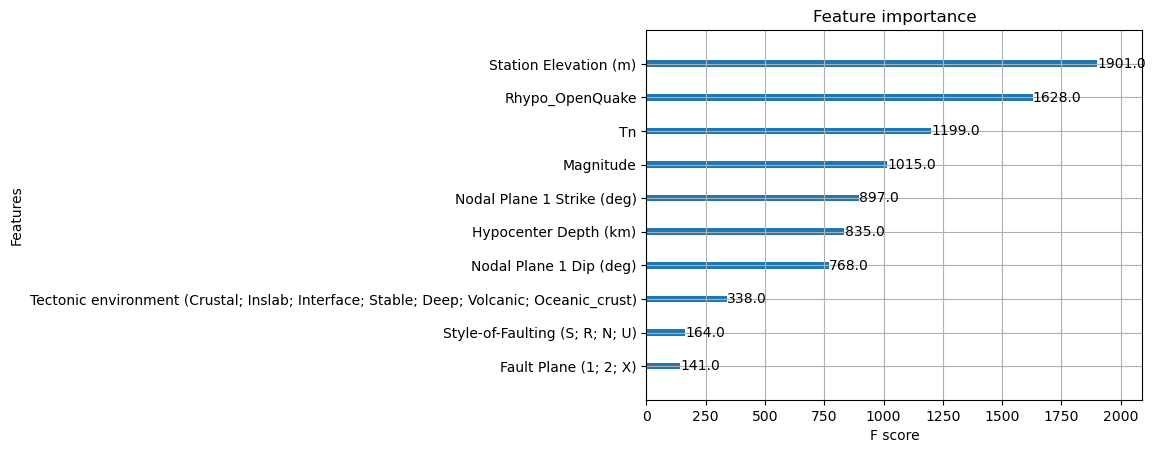

In [75]:
xgb.plot_importance(f_importance)
plt.show()

### SVM

In [76]:
from sklearn.svm import SVR

In [77]:
pipeSVM = Pipeline([("scaler", MinMaxScaler()), ("svm", SVR(kernel ='rbf', shrinking = True))])

In [78]:
param_gridSVM = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100], 
              'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
              'svm__epsilon': [0.001, 0.01, 0.1, 0.5, 1.0],
}

In [79]:
"""grid_searchSVM = GridSearchCV(pipeSVM, param_grid=param_gridSVM, scoring='neg_root_mean_squared_error', cv=5, n_jobs=6)
grid_searchSVM.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(-grid_searchSVM.best_score_))
print("Test set score: {:.2f}".format(-grid_searchSVM.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchSVM.best_params_))"""

'grid_searchSVM = GridSearchCV(pipeSVM, param_grid=param_gridSVM, scoring=\'neg_root_mean_squared_error\', cv=5, n_jobs=6)\ngrid_searchSVM.fit(X_train, y_train)\nprint("Best cross-validation accuracy: {:.2f}".format(-grid_searchSVM.best_score_))\nprint("Test set score: {:.2f}".format(-grid_searchSVM.score(X_test, y_test)))\nprint("Best parameters: {}".format(grid_searchSVM.best_params_))'

In [80]:
pipeSVMnuevo = Pipeline([('scaler', MinMaxScaler()),('svm', SVR(C=300,gamma=0.01,epsilon=0.1,kernel='rbf',shrinking=True))])

In [81]:
pipeSVMnuevo.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('svm', SVR(C=300, gamma=0.01))])

In [82]:
print("Train score: {:.2f}".format(pipeSVMnuevo.score(X_train, y_train)))
print("Test score: {:.2f}".format(pipeSVMnuevo.score(X_test, y_test)))

Train score: 0.70
Test score: 0.68


In [83]:
y_pred_SVM = pipeSVMnuevo.predict(X_test)
y_pred_SVM_todos = pipeSVMnuevo.predict(X_final)

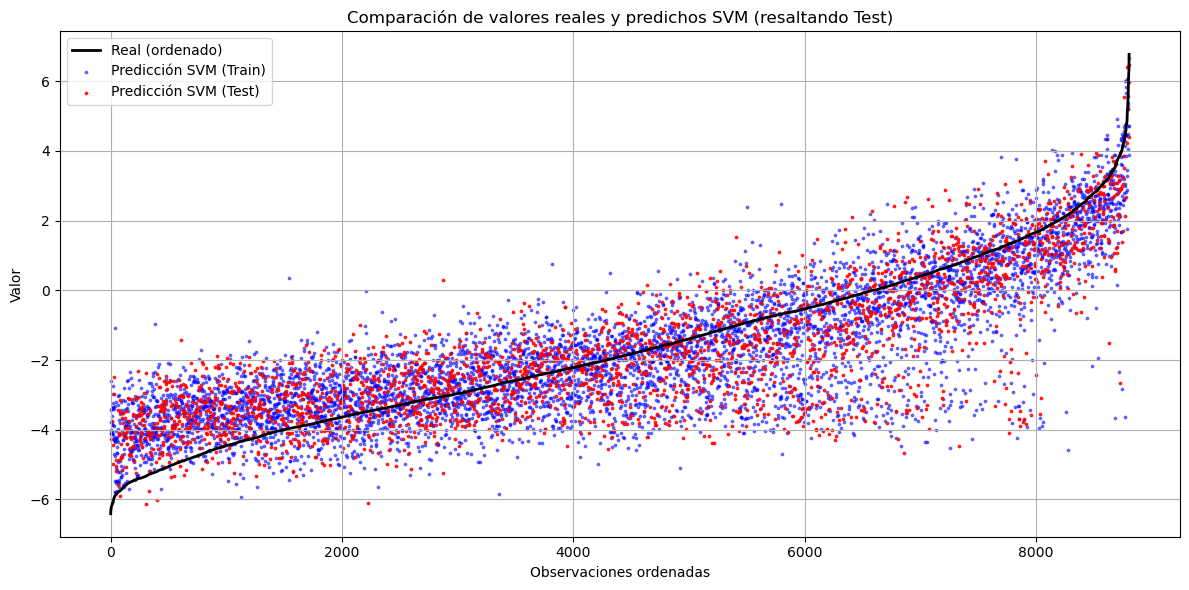

In [84]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_SVM_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción SVM (Train)', color='blue', s=3, alpha=0.5)

# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción SVM (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos SVM (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Meta Stacking

In [85]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
import lightgbm as lgb
from sklearn.linear_model import HuberRegressor, BayesianRidge, QuantileRegressor, TheilSenRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel


In [86]:
# Metamodelo robusto: tolera outliers en errores de modelos base
"""meta_model = Pipeline([
    ('scaler',MinMaxScaler()),
    ('reg',LinearRegression())]
)"""
meta_model = LinearRegression()




In [87]:
stack = StackingRegressor(
    estimators=[],  # por defecto, pero se cambiará con el grid
    final_estimator=meta_model,
    passthrough=False,
    n_jobs=-1
)

In [88]:
param_grid_Stacking = {
    'estimators': [
        [('xgb', pipeXGBnuevo), ('svm', pipeSVMnuevo), ('knn', pipeKNNnuevo), ('rf', pipeRFnuevo) ],
        [('xgb', pipeXGBnuevo), ('svm', pipeSVMnuevo), ('knn', pipeKNNnuevo)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo), ('svm', pipeSVMnuevo)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo), ('knn', pipeKNNnuevo)],
        [('xgb', pipeXGBnuevo), ('svm', pipeSVMnuevo), ('reg', pipeLINEAL)],
        [('svm', pipeSVMnuevo), ('knn', pipeKNNnuevo), ('reg', pipeLINEAL)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo), ('reg', pipeLINEAL)],
        [('svm', pipeSVMnuevo), ('rf', pipeRFnuevo), ('reg', pipeLINEAL)],
        [('xgb', pipeXGBnuevo), ('rf', pipeRFnuevo)],
        [('xgb', pipeXGBnuevo), ('reg', pipeLINEAL)],
        [('svm', pipeSVMnuevo), ('reg', pipeLINEAL)]
    ]}


In [89]:
"""grid_searchStacking = GridSearchCV(estimator=stack,param_grid=param_grid_Stacking,cv=5,scoring='r2',n_jobs=-1)
grid_searchStacking.fit(X_train, y_train)"""

"grid_searchStacking = GridSearchCV(estimator=stack,param_grid=param_grid_Stacking,cv=5,scoring='r2',n_jobs=-1)\ngrid_searchStacking.fit(X_train, y_train)"

In [90]:
"""print("Best cross-validation accuracy: {:.2f}".format(-grid_searchStacking.best_score_))
print("Test set score: {:.2f}".format(-grid_searchStacking.score(X_test, y_test)))
print("Best parameters: {}".format(grid_searchStacking.best_params_))"""

'print("Best cross-validation accuracy: {:.2f}".format(-grid_searchStacking.best_score_))\nprint("Test set score: {:.2f}".format(-grid_searchStacking.score(X_test, y_test)))\nprint("Best parameters: {}".format(grid_searchStacking.best_params_))'

In [91]:
#meta_model = lgb.LGBMRegressor()

estimators = [
    #('gbr', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05)),
    #('et', ExtraTreesRegressor(n_estimators=100, max_depth=12, random_state=0)),
    #('ada', AdaBoostRegressor(n_estimators=100, learning_rate=0.1)),
    ('cat', CatBoostRegressor()),
    #('lgb', lgb.LGBMRegressor()),
    #('bayes', BayesianRidge()),
    #('quant', QuantileRegressor(quantile=0.5, alpha=1.0, solver='highs')),
    #('theil', TheilSenRegressor()),
    #('mlp', MLPRegressor(hidden_layer_sizes=(80, 40), max_iter=2000, early_stopping=True, random_state=0)),
    #('histgb', HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05))
    #('svm', pipeSVMnuevo)
    ('rf', RandomForestRegressor())
]


In [92]:
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,  # Validación cruzada para entrenar el meta-modelo
    n_jobs=-1,  # Paralelizar si es posible
    passthrough= False
)

In [93]:
stacking_model.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('cat',
                               <catboost.core.CatBoostRegressor object at 0x0000028FE4733A90>),
                              ('rf', RandomForestRegressor())],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [94]:
y_train_pred_stacking = stacking_model.predict(X_train)
y_test_pred_stacking = stacking_model.predict(X_test)
y_pred_stacking_todos = stacking_model.predict(X_final)

In [95]:
print("Train R²:", r2_score(y_train, y_train_pred_stacking))
print("Test R²:", r2_score(y_test, y_test_pred_stacking))

Train R²: 0.9394609062177381
Test R²: 0.8600448219145432


In [96]:
print("Pesos del meta-modelo:", stacking_model.final_estimator_.coef_)

Pesos del meta-modelo: [0.88327722 0.14359748]


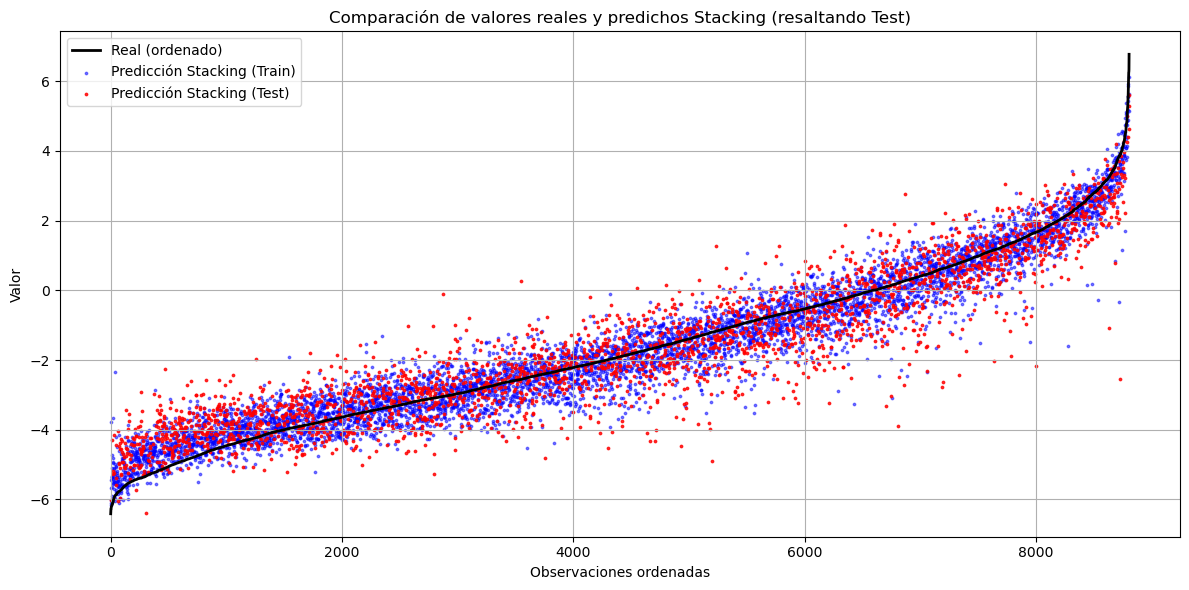

In [97]:
# Ordenar y obtener predicciones correspondientes
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_stacking_todos[orden]

# Crear una máscara booleana para los puntos que están en y_test
es_test = np.isin(y_real_ordenado, y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)

# Puntos de entrenamiento
plt.scatter(np.where(~es_test)[0], y_pred_correspondiente[~es_test],
            label='Predicción Stacking (Train)', color='blue', s=3, alpha=0.5)

# Puntos de test
plt.scatter(np.where(es_test)[0], y_pred_correspondiente[es_test],
            label='Predicción Stacking (Test)', color='red', s=3, alpha=0.8)

plt.title('Comparación de valores reales y predichos Stacking (resaltando Test)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Tabla de métricas

In [98]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score,mean_absolute_error
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox


epsilon = 1e-6  # Pequeño valor para evitar divisiones por cero

#MAPE

mape_knn = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_knn) * 100
mape_regl = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_reglineal) * 100
mape_ridge = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_Ridge) * 100
mape_lasso = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_Lasso) * 100
mape_rand = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_RAND) * 100
mape_xgb = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_XGB) * 100
mape_svm = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_SVM) * 100
mape_stacking = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_test_pred_stacking) * 100

#MAE

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mae_regl = mean_absolute_error(y_test, y_pred_reglineal)
mae_ridge = mean_absolute_error(y_test, y_pred_Ridge)
mae_lasso = mean_absolute_error(y_test, y_pred_Lasso)
mae_rand = mean_absolute_error(y_test, y_pred_RAND)
mae_xgb = mean_absolute_error(y_test, y_pred_XGB)
mae_svm = mean_absolute_error(y_test, y_pred_SVM)
mae_stacking = mean_absolute_error(y_test, y_test_pred_stacking)

#RMSE

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))  # RMSE
rmse_regl = np.sqrt(mean_squared_error(y_test, y_pred_reglineal))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_Ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_Lasso))
rmse_rand = np.sqrt(mean_squared_error(y_test, y_pred_RAND))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_XGB))
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_SVM))
rmse_stacking = np.sqrt(mean_squared_error(y_test, y_test_pred_stacking))

#R2

r2_knn = r2_score(y_test, y_pred_knn)  # R²
r2_regl = r2_score(y_test, y_pred_reglineal)  # R²
r2_ridge = r2_score(y_test, y_pred_Ridge)  # R²
r2_lasso = r2_score(y_test, y_pred_Lasso)  # R²
r2_rand = r2_score(y_test, y_pred_RAND)  # R²
r2_xgb = r2_score(y_test, y_pred_XGB)
r2_svm = r2_score(y_test, y_pred_SVM)  # R²
r2_stacking = r2_score(y_test, y_test_pred_stacking)  # R²

# Calcular Ljung-Box (test de autocorrelación de residuos)

residuos_knn = y_test - y_pred_knn
ljung_box_knn = acorr_ljungbox(residuos_knn, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_regl = y_test - y_pred_reglineal
ljung_box_regl = acorr_ljungbox(residuos_regl, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_ridge = y_test - y_pred_Ridge
ljung_box_ridge = acorr_ljungbox(residuos_ridge, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_lasso = y_test - y_pred_Lasso
ljung_box_lasso = acorr_ljungbox(residuos_lasso, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_rand = y_test - y_pred_RAND
ljung_box_rand = acorr_ljungbox(residuos_rand, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_xgb = y_test - y_pred_XGB
ljung_box_xgb = acorr_ljungbox(residuos_xgb, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_svm = y_test - y_pred_SVM
ljung_box_svm = acorr_ljungbox(residuos_svm, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_stacking = y_test - y_test_pred_stacking
ljung_box_stacking = acorr_ljungbox(residuos_stacking, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value

# Calcular Jarque-Bera (test de normalidad de residuos)

jb_test_knn = jarque_bera(residuos_knn)
jarque_bera_knn = jb_test_knn.pvalue  # p-value
jb_test_regl = jarque_bera(residuos_regl)
jarque_bera_regl = jb_test_regl.pvalue
jb_test_ridge = jarque_bera(residuos_ridge)
jarque_bera_ridge = jb_test_ridge.pvalue
jb_test_lasso = jarque_bera(residuos_lasso)
jarque_bera_lasso = jb_test_lasso.pvalue
jb_test_rand = jarque_bera(residuos_rand)
jarque_bera_rand = jb_test_rand.pvalue
jb_test_xgb = jarque_bera(residuos_xgb)
jarque_bera_xgb = jb_test_xgb.pvalue
jb_test_svm = jarque_bera(residuos_svm)
jarque_bera_svm = jb_test_svm.pvalue
jb_test_stacking = jarque_bera(residuos_stacking)
jarque_bera_stacking = jb_test_stacking.pvalue


tabla_resultados = pd.DataFrame({
    'Modelo': ['K-NN','Regresión Lineal','Regresión Ridge','Regresión Lasso','Random Forest','XGBoost','SVM','Stacking'],
    'MAE': [mae_knn, mae_regl, mae_ridge, mae_lasso, mae_rand, mae_xgb, mae_svm,mae_stacking],
    'RMSE': [rmse_knn, rmse_regl, rmse_ridge, rmse_lasso, rmse_rand, rmse_xgb, rmse_svm,rmse_stacking],
    'R²': [r2_knn, r2_regl, r2_ridge, r2_lasso, r2_rand, r2_xgb, r2_svm,r2_stacking],
    'Ljung-Box p-value': [ljung_box_knn, ljung_box_regl, ljung_box_ridge, ljung_box_lasso, ljung_box_rand, ljung_box_xgb, ljung_box_svm,ljung_box_stacking],
    'Jarque-Bera p-value': [jarque_bera_knn, jarque_bera_regl, jarque_bera_ridge, jarque_bera_lasso, jarque_bera_rand, jarque_bera_xgb, jarque_bera_svm,jarque_bera_stacking]
})


In [99]:
tabla_resultados

,Modelo,MAE,RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,K-NN,1.087727,1.380024,0.644261,0.278273,2.042609e-23
1,Regresión Lineal,1.091288,1.392489,0.637805,0.786225,5.794007e-38
2,Regresión Ridge,1.091540,1.393594,0.637230,0.845846,6.203846e-38
3,Regresión Lasso,1.092682,1.395503,0.636236,0.874495,9.424036e-38
4,Random Forest,0.889094,1.124339,0.763869,0.646184,7.348095e-23
5,XGBoost,0.770526,0.987792,0.817741,0.532367,7.159677e-46
6,SVM,0.998944,1.318057,0.675491,0.735189,1.105198e-89
7,Stacking,0.657735,0.865596,0.860045,0.944214,1.910119e-170


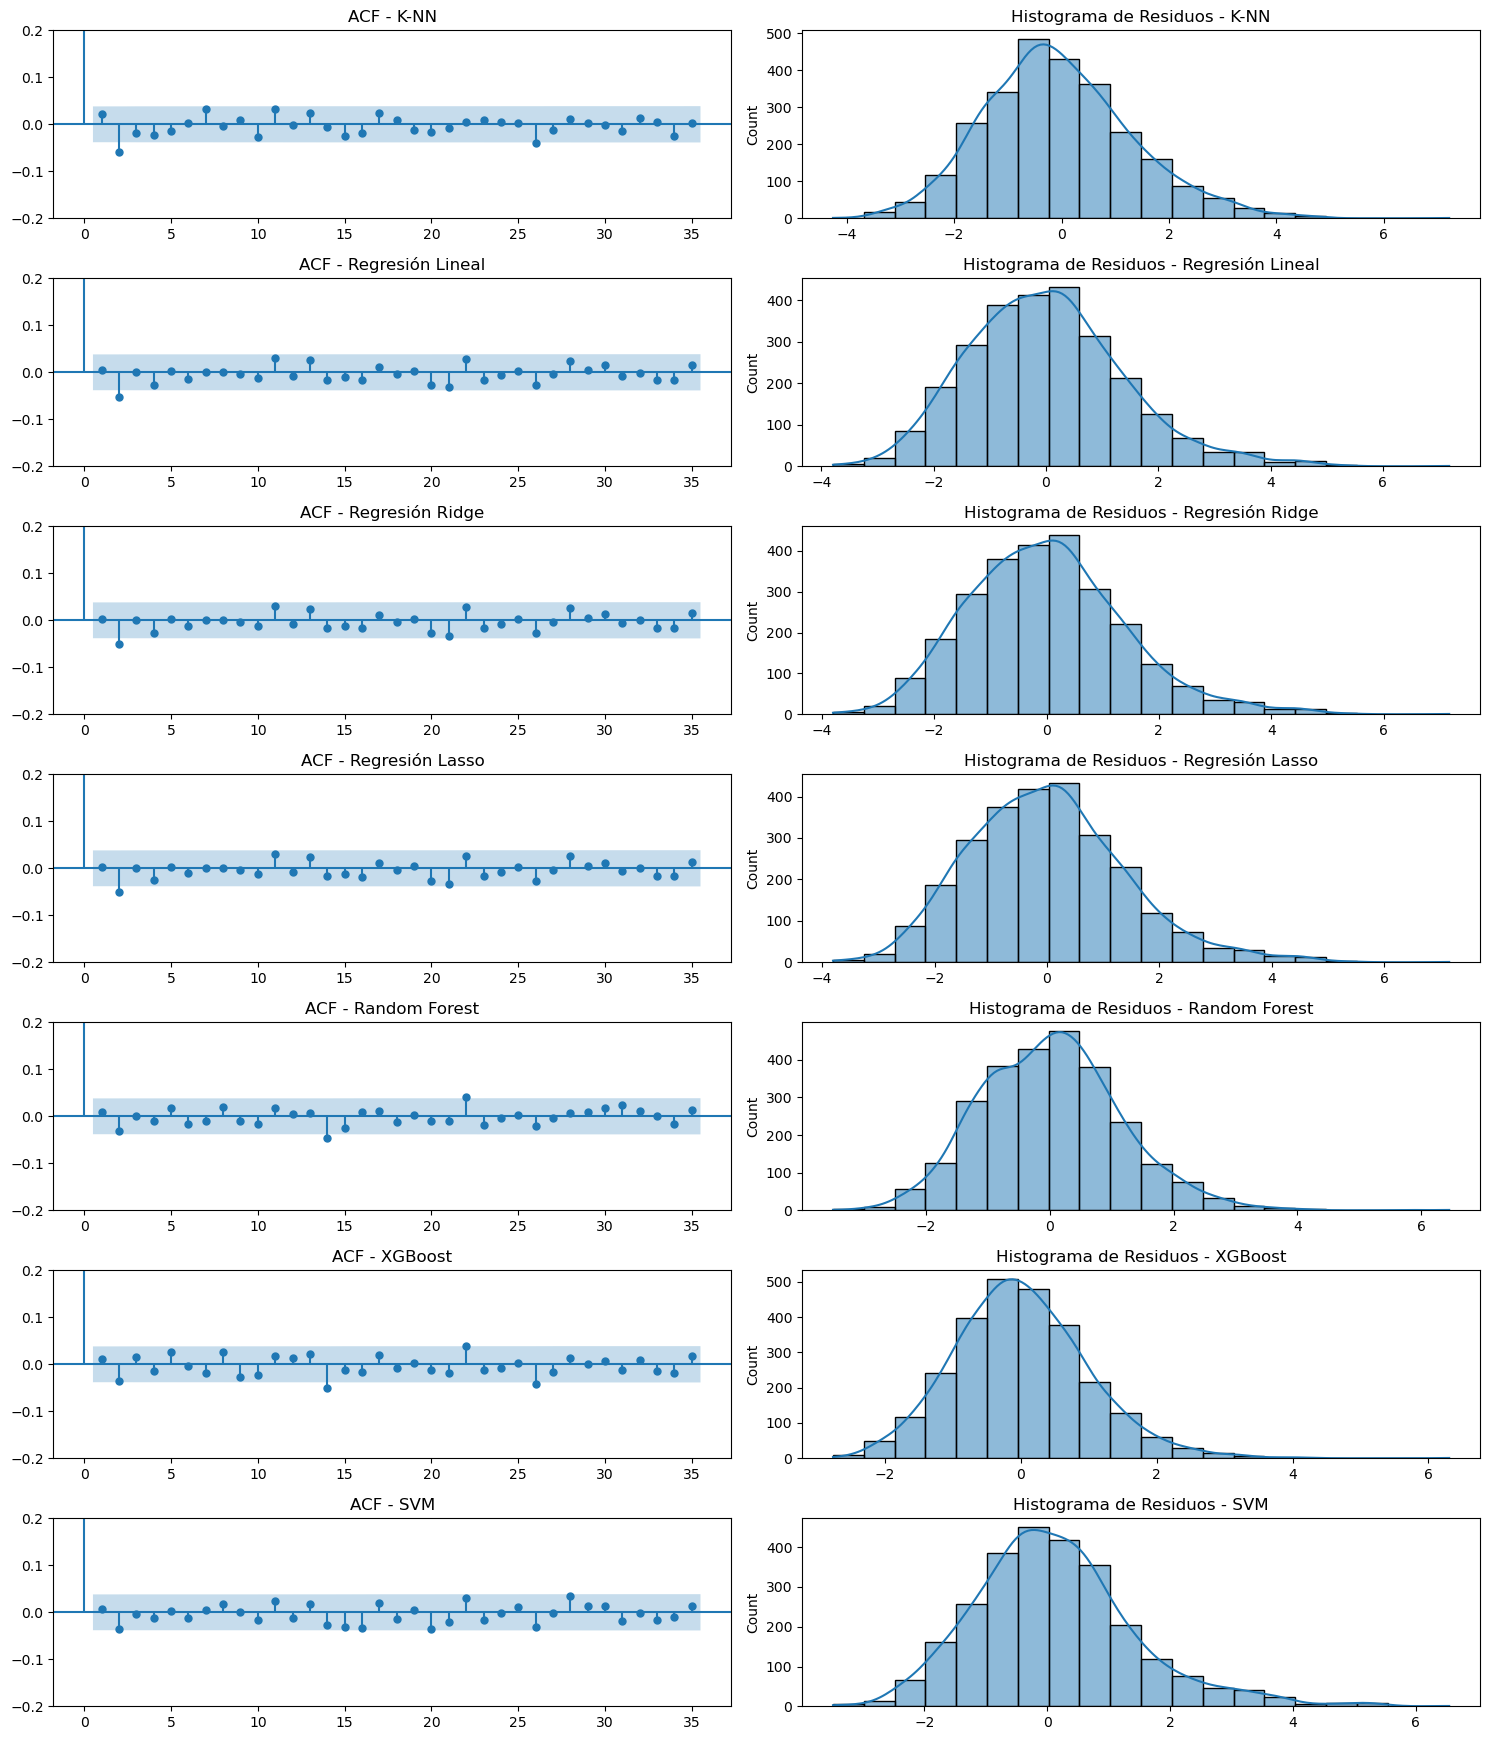

In [100]:
from statsmodels.graphics.tsaplots import plot_acf
modelos = {
    "K-NN": residuos_knn,
    "Regresión Lineal": residuos_regl,
    "Regresión Ridge": residuos_ridge,
    "Regresión Lasso": residuos_lasso,
    "Random Forest": residuos_rand,
    "XGBoost": residuos_xgb,
    "SVM": residuos_svm
}

fig, axes = plt.subplots(len(modelos), 2, figsize=(15, 2.5 * len(modelos)))

for i, (nombre, residuos) in enumerate(modelos.items()):
    # ACF de los residuos
    plot_acf(residuos, ax=axes[i, 0], title=f"ACF - {nombre}")
    axes[i,0].set_ylim(-0.2, 0.2)  # Límite en el eje y
    # Histograma de los residuos
    sns.histplot(residuos, bins=20, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Histograma de Residuos - {nombre}")
    

plt.tight_layout()
plt.show()

In [101]:
residuos_knn_total = y-y_pred_knn_todos
residuos_regl_total = y-y_pred_reglineal_todos
residuos_ridge_total = y-y_pred_Ridge_todos
residuos_lasso_total = y-y_pred_Lasso_todos
residuos_rand_total = y-y_pred_RAND_todos
residuos_xgb_total = y-y_pred_XGB_todos
residuos_svm_total = y-y_pred_SVM_todos
residuos_stacking_total = y-y_pred_stacking_todos
residuos_total = pd.DataFrame({
    'K-NN': residuos_knn_total,
    'Regresión Lineal': residuos_regl_total,
    'Regresión Ridge': residuos_ridge_total,
    'Regresión Lasso': residuos_lasso_total,
    'Random Forest': residuos_rand_total,
    'XGBoost': residuos_xgb_total,
    'SVM': residuos_svm_total,
    'Stacking': residuos_stacking_total
})

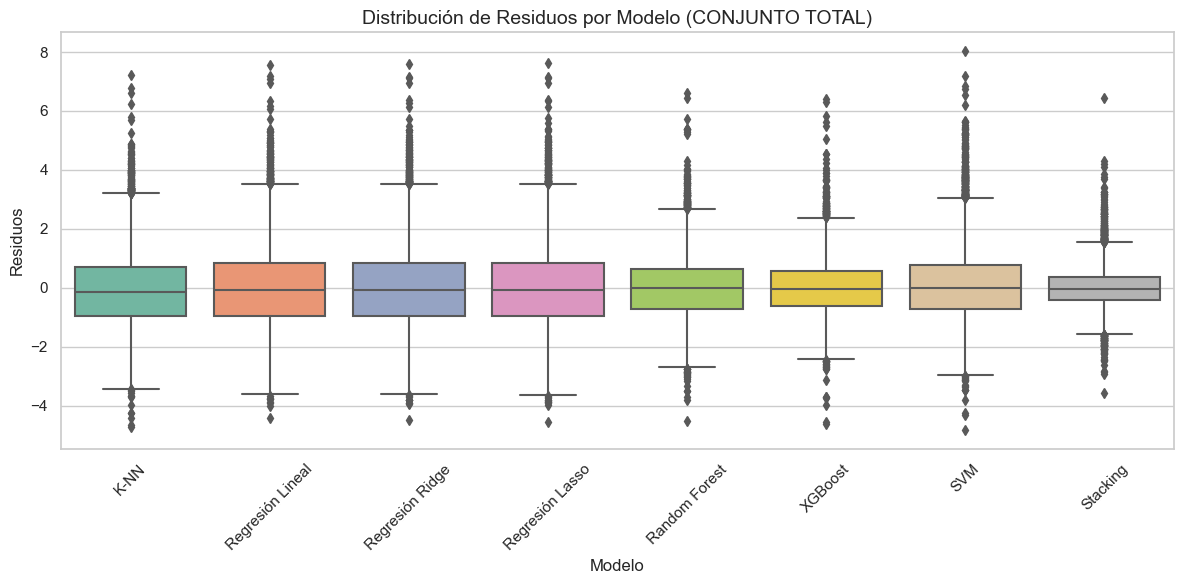

In [102]:
residuos_reales_largo = residuos_total.melt(var_name='Modelo', value_name='Residuos')
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.boxplot(x='Modelo', y='Residuos', data=residuos_reales_largo, palette="Set2")

plt.title('Distribución de Residuos por Modelo (CONJUNTO TOTAL)', fontsize=14)
plt.xlabel('Modelo')
plt.ylabel('Residuos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [103]:
import plotly.express as px

fig = px.box(
    residuos_reales_largo,
    x='Modelo',
    y='Residuos',
    color='Modelo',
    title='Distribución de Residuos por Modelo (CONJUNTO TOTAL)',
    template='plotly_white',
    width=1000,
    height=600
)

fig.update_layout(
    xaxis_title='Modelo',
    yaxis_title='Residuos',
    showlegend=False,
    margin=dict(t=60)
)

fig.show()


In [104]:
residuos_total.describe().T

,count,mean,std,min,25%,50%,75%,max
K-NN,8805.0,-0.067248,1.291687,-4.744875,-0.944379,-0.135585,0.713805,7.215986
Regresión Lineal,8805.0,0.004227,1.369959,-4.436312,-0.953988,-0.074371,0.833482,7.553798
Regresión Ridge,8805.0,0.003882,1.371386,-4.502408,-0.954756,-0.073938,0.836357,7.595279
Regresión Lasso,8805.0,0.003658,1.373725,-4.544291,-0.955886,-0.073250,0.840596,7.619076
Random Forest,8805.0,0.005318,1.058193,-4.515100,-0.713661,-0.016607,0.645951,6.613149
XGBoost,8805.0,0.003356,0.942905,-4.634415,-0.625020,-0.045331,0.574439,6.401959
SVM,8805.0,0.103864,1.280459,-4.834771,-0.728242,0.001717,0.785092,8.026729
Stacking,8805.0,-0.002406,0.674296,-3.562280,-0.412440,-0.036079,0.367428,6.425664


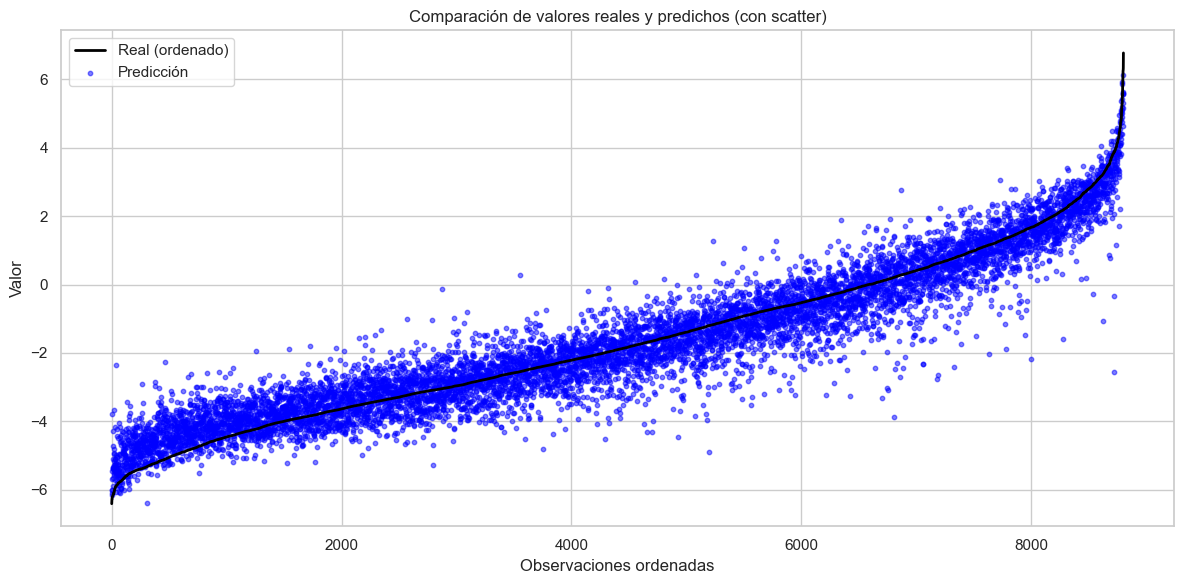

In [105]:
# 1. Orden
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_correspondiente = y_pred_stacking_todos[orden]

# 2. Gráfica
plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Real (ordenado)', color='black', linewidth=2)
plt.scatter(range(len(y_pred_correspondiente)), y_pred_correspondiente,
            label='Predicción', color='blue', s=10, alpha=0.5)
plt.title('Comparación de valores reales y predichos (con scatter)')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [106]:
import plotly.graph_objects as go
import numpy as np

orden = np.argsort(y)
y_real_orden = y[orden]
y_real_ordenado = np.exp(y_real_orden)
y_pred_correspondiente = np.exp(y_pred_stacking_todos[orden])

# Crear figura interactiva
fig = go.Figure()

# Línea de valores reales ordenados
fig.add_trace(go.Scatter(
    y=y_real_ordenado,
    mode='lines',
    name='Real (ordenado)',
    line=dict(color='black', width=2)
))

# Puntos de predicciones correspondientes
fig.add_trace(go.Scatter(
    y=y_pred_correspondiente,
    mode='markers',
    name='Predicción',
    marker=dict(color='blue', size=4, opacity=0.5)
))

# Configuración del layout
fig.update_layout(
    title='Comparación de valores reales y predichos (interactivo)',
    xaxis_title='Observaciones ordenadas',
    yaxis_title='Valor',
    xaxis=dict(range=[0, 8000]),
    yaxis=dict(range=[0, 25]),
    legend=dict(x=0.01, y=0.99),
    height=600,
    width=1000
)

# Mostrar
fig.show()


## Meta Modelos

### Meta modelo elegido

In [107]:
# Definir índice para comportamiento lineal (Sa <= 0.05g)

idx_lineal = y_train <= 0.1
idx_no_lineal = y_train > 0.1


In [108]:
X_lineal = X_train[idx_lineal]
y_lineal = y_train[idx_lineal]

X_no_lineal = X_train[idx_no_lineal]
y_no_lineal = y_train[idx_no_lineal]


In [109]:

modelo_lineal = modelo_lineal = CatBoostRegressor(
)
modelo_lineal.fit(X_lineal, y_lineal)

modelo_no_lineal = lgb.LGBMRegressor(n_estimators=200, max_depth=10)

modelo_no_lineal.fit(X_no_lineal, y_no_lineal)



Learning rate set to 0.052293
0:	learn: 1.5371200	total: 107ms	remaining: 1m 47s
1:	learn: 1.5124546	total: 110ms	remaining: 54.7s
2:	learn: 1.4886391	total: 113ms	remaining: 37.4s
3:	learn: 1.4666333	total: 115ms	remaining: 28.5s
4:	learn: 1.4459097	total: 117ms	remaining: 23.2s
5:	learn: 1.4263303	total: 119ms	remaining: 19.7s
6:	learn: 1.4089023	total: 121ms	remaining: 17.1s
7:	learn: 1.3937801	total: 123ms	remaining: 15.2s
8:	learn: 1.3777914	total: 125ms	remaining: 13.7s
9:	learn: 1.3599029	total: 127ms	remaining: 12.6s
10:	learn: 1.3457988	total: 129ms	remaining: 11.6s
11:	learn: 1.3340716	total: 131ms	remaining: 10.8s
12:	learn: 1.3191604	total: 133ms	remaining: 10.1s
13:	learn: 1.3085448	total: 135ms	remaining: 9.48s
14:	learn: 1.2981000	total: 137ms	remaining: 8.99s
15:	learn: 1.2855963	total: 139ms	remaining: 8.53s
16:	learn: 1.2748387	total: 140ms	remaining: 8.12s
17:	learn: 1.2659764	total: 142ms	remaining: 7.75s
18:	learn: 1.2578034	total: 144ms	remaining: 7.44s
19:	learn:

LGBMRegressor(max_depth=10, n_estimators=200)

In [110]:
# Comportamiento real según y (log(Sa))
comportamiento_real = np.where(y <= 0.1, 'lineal', 'no_lineal')


In [111]:
from sklearn.ensemble import RandomForestClassifier

selector = RandomForestClassifier(n_estimators=100, random_state=0)
selector.fit(X_final, comportamiento_real)


RandomForestClassifier(random_state=0)

In [112]:
# Predicción del selector para cada muestra train
modelo_elegido2 = selector.predict(X_train)

# Predicciones de ambos modelos sobre train el dataset
y_pred_lineal_train = modelo_lineal.predict(X_train)
y_pred_no_lineal_train = modelo_no_lineal.predict(X_train)

# Combinar según el modelo seleccionado
y_pred_final2 = np.where(
    modelo_elegido2 == 'lineal',
    y_pred_lineal_train,
    y_pred_no_lineal_train
)

In [113]:
# Predicción del selector para cada muestra test
modelo_elegido3 = selector.predict(X_test)

# Predicciones de ambos modelos sobre test el dataset
y_pred_lineal_test = modelo_lineal.predict(X_test)
y_pred_no_lineal_test = modelo_no_lineal.predict(X_test)

# Combinar según el modelo seleccionado
y_pred_final3 = np.where(
    modelo_elegido3 == 'lineal',
    y_pred_lineal_test,
    y_pred_no_lineal_test
)

In [114]:
print(len(X_train), len(X_lineal),len(X_no_lineal))
print(len(X_lineal), np.sum(modelo_elegido3 == 'lineal'))
print(len(X_no_lineal), np.sum(modelo_elegido3 == 'no_lineal'))

6163 4705 1458
4705 1998
1458 644


In [115]:
# Predicción del selector para cada muestra total
modelo_elegido = selector.predict(X_final)

# Predicciones de ambos modelos sobre TODO el dataset
y_pred_lineal = modelo_lineal.predict(X_final)
y_pred_no_lineal = modelo_no_lineal.predict(X_final)

# Combinar según el modelo seleccionado
y_pred_final = np.where(
    modelo_elegido == 'lineal',
    y_pred_lineal,
    y_pred_no_lineal
)


In [116]:
# Esto refleja lo que el modelo realmente aprendió
true_mask_lineal = y_test <= 0.1
print("R² modelo lineal en muestras verdaderamente lineales:", r2_score(y_test[true_mask_lineal], modelo_lineal.predict(X_test[true_mask_lineal])))
true_mask_no_lineal = y_test > 0.1
print("R² modelo no lineal en no lineales reales:", r2_score(y_test[true_mask_no_lineal], modelo_no_lineal.predict(X_test[true_mask_no_lineal])))



R² modelo lineal en muestras verdaderamente lineales: 0.7253693604293541
R² modelo no lineal en no lineales reales: 0.6178880188859415


In [117]:
from sklearn.metrics import confusion_matrix

# Comparar selector vs. etiqueta real
etiqueta_real = np.where(y_test > np.log(0.05), 'no_lineal', 'lineal')
print(confusion_matrix(etiqueta_real, modelo_elegido3, labels=['lineal', 'no_lineal']))


[[ 889    0]
 [1109  644]]


In [118]:
print("R² lineal train:", r2_score(y_lineal, modelo_lineal.predict(X_lineal)))
print("RMSE lineal train:", root_mean_squared_error(y_lineal, modelo_lineal.predict(X_lineal)))
print("R² no lineal test:", r2_score(y_no_lineal, modelo_no_lineal.predict(X_no_lineal)))
print("RMSE no lineal test:", root_mean_squared_error(y_no_lineal, modelo_no_lineal.predict(X_no_lineal)))

R² lineal train: 0.8714381619279514
RMSE lineal train: 0.5610848232937121
R² no lineal test: 0.9684474209745709
RMSE no lineal test: 0.19866997605391878


In [119]:
print("R² combinado train:", r2_score(y_train, y_pred_final2))
print("RMSE combinado train:", root_mean_squared_error(y_train, y_pred_final2))
print("R² combinado test:", r2_score(y_test, y_pred_final3))
print("RMSE combinado test:", root_mean_squared_error(y_test, y_pred_final3))
print("R² combinado: total", r2_score(y, y_pred_final))
print("RMSE combinado: total", root_mean_squared_error(y, y_pred_final))


R² combinado train: 0.9539628351562047
RMSE combinado train: 0.49967651892837023
R² combinado test: 0.8822624125428489
RMSE combinado test: 0.7939226188591982
R² combinado: total 0.9326438655982691
RMSE combinado: total 0.6032322842086072


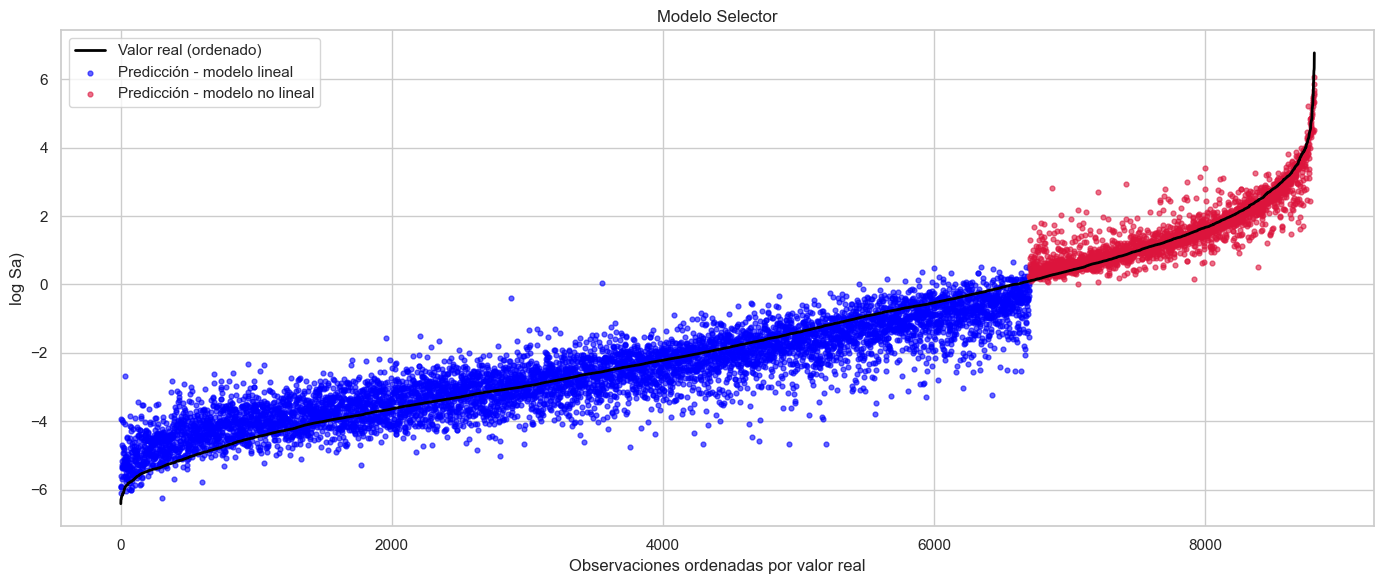

In [120]:

# Convertir a arrays (por si no lo son)
y = np.array(y)
y_pred_final = np.array(y_pred_final)
modelo_elegido = np.array(modelo_elegido)

# 1. Ordenar por el valor real
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_ordenado = y_pred_final[orden]
modelo_ordenado = modelo_elegido[orden]

# 2. Separar los índices según el modelo activado
idx_lineal = np.where(modelo_ordenado == 'lineal')[0]
idx_no_lineal = np.where(modelo_ordenado == 'no_lineal')[0]

# 3. Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_real_ordenado, label='Valor real (ordenado)', color='black', linewidth=2)
plt.scatter(idx_lineal, y_pred_ordenado[idx_lineal],
            color='blue', s=12, alpha=0.6, label='Predicción - modelo lineal')

plt.scatter(idx_no_lineal, y_pred_ordenado[idx_no_lineal],
            color='crimson', s=12, alpha=0.6, label='Predicción - modelo no lineal')

plt.title('Modelo Selector')
plt.xlabel('Observaciones ordenadas por valor real')
plt.ylabel('log Sa)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [121]:
import numpy as np
import plotly.graph_objects as go

# Asegúrate de tener:
# yexp                → np.exp(y)
# y_pred_finalexp     → np.exp(y_pred_final)
# modelo_elegido      → array con 'lineal' o 'no_lineal'

# Ordenar por valor real
orden = np.argsort(y)
y_real_ordenado = y[orden]
y_pred_ordenado = y_pred_final[orden]
modelo_ordenado = modelo_elegido[orden]

# Separar índices por tipo de modelo
idx_lineal = np.where(modelo_ordenado == 'lineal')[0]
idx_no_lineal = np.where(modelo_ordenado == 'no_lineal')[0]

# Crear figura interactiva
fig = go.Figure()

# Línea de valores reales
fig.add_trace(go.Scatter(
    x=np.arange(len(y_real_ordenado)),
    y=y_real_ordenado,
    mode='lines',
    name='Valor real (ordenado)',
    line=dict(color='black')
))

# Puntos del modelo lineal
fig.add_trace(go.Scatter(
    x=idx_lineal,
    y=y_pred_ordenado[idx_lineal],
    mode='markers',
    name='Predicción - modelo lineal',
    marker=dict(color='blue', size=6, opacity=0.7)
))

# Puntos del modelo no lineal
fig.add_trace(go.Scatter(
    x=idx_no_lineal,
    y=y_pred_ordenado[idx_no_lineal],
    mode='markers',
    name='Predicción - modelo no lineal',
    marker=dict(color='crimson', size=6, opacity=0.7)
))

# Layout
fig.update_layout(
    title='Comparación de valores reales vs predichos (por modelo activado)',
    xaxis_title='Observaciones ordenadas por valor real',
    yaxis_title='Valor objetivo (Sa)',
    legend=dict(x=0.01, y=0.99),
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()


In [122]:
np.exp(-0.5985)-np.exp(-3.85)

0.5283557348317032

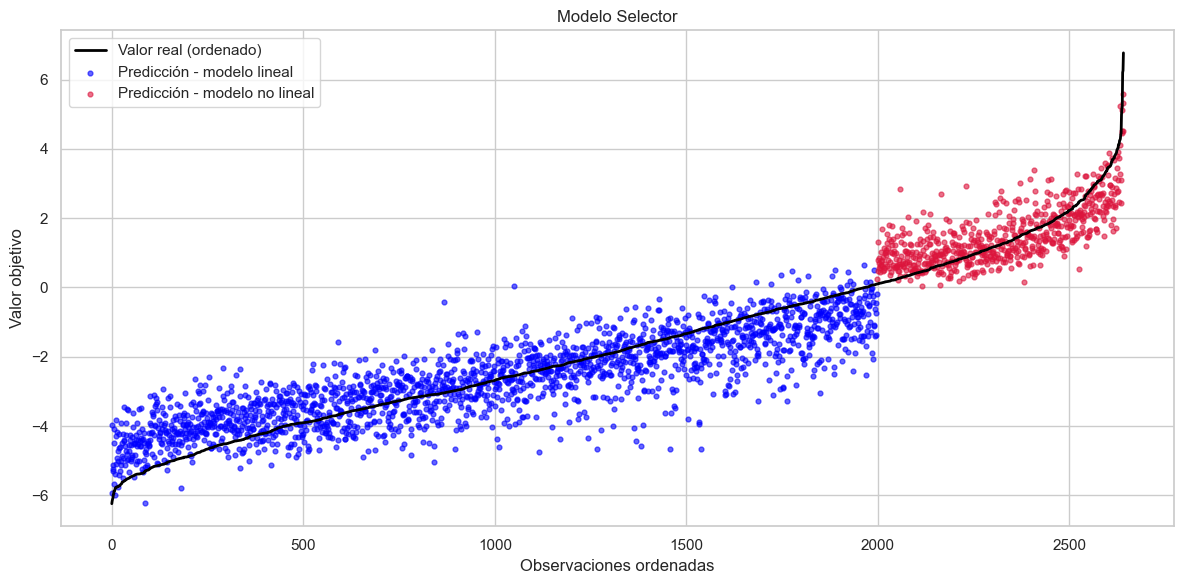

In [123]:
modelo_elegido3 = np.array(modelo_elegido3)  # por si viene como lista
orden = np.argsort(y_test)

# Ordenar todos los arrays
y_real_ordenado = y_test[orden]
y_pred_ordenado = y_pred_final3[orden]
modelo_ordenado = modelo_elegido3[orden]

# Separar los puntos según modelo usado
indices_lineal = np.where(modelo_ordenado == 'lineal')[0]
indices_no_lineal = np.where(modelo_ordenado == 'no_lineal')[0]

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(y_real_ordenado, label='Valor real (ordenado)', color='black', linewidth=2)

plt.scatter(indices_lineal, y_pred_ordenado[indices_lineal],
            label='Predicción - modelo lineal', color='blue', s=12, alpha=0.6)

plt.scatter(indices_no_lineal, y_pred_ordenado[indices_no_lineal],
            label='Predicción - modelo no lineal', color='crimson', s=12, alpha=0.6)

plt.title('Modelo Selector')
plt.xlabel('Observaciones ordenadas')
plt.ylabel('Valor objetivo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [124]:
residuos_selector = y - y_pred_final

In [125]:
residuos_total['Selector']=residuos_selector

In [126]:
residuos_total.describe().T

,count,mean,std,min,25%,50%,75%,max
K-NN,8805.0,-0.067248,1.291687,-4.744875,-0.944379,-0.135585,0.713805,7.215986
Regresión Lineal,8805.0,0.004227,1.369959,-4.436312,-0.953988,-0.074371,0.833482,7.553798
Regresión Ridge,8805.0,0.003882,1.371386,-4.502408,-0.954756,-0.073938,0.836357,7.595279
Regresión Lasso,8805.0,0.003658,1.373725,-4.544291,-0.955886,-0.073250,0.840596,7.619076
Random Forest,8805.0,0.005318,1.058193,-4.515100,-0.713661,-0.016607,0.645951,6.613149
XGBoost,8805.0,0.003356,0.942905,-4.634415,-0.625020,-0.045331,0.574439,6.401959
SVM,8805.0,0.103864,1.280459,-4.834771,-0.728242,0.001717,0.785092,8.026729
Stacking,8805.0,-0.002406,0.674296,-3.562280,-0.412440,-0.036079,0.367428,6.425664
Selector,8805.0,-0.000867,0.603266,-3.226457,-0.338453,-0.013235,0.309042,3.473954


In [127]:
for idx, residuo in enumerate(residuos_selector):
    if residuo > 3:
        print(idx)


2540
4135
4499


In [128]:
indices = [idx for idx, residuo in enumerate(residuos_selector) if residuo > 3]

In [129]:
filas_filtradas = df_copy.iloc[indices]
filas_filtradas

,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Fault Plane (1; 2; X),Style-of-Faulting (S; R; N; U),Station Elevation (m),Tn,Rhypo_OpenQuake,T_0.01_RotD50
2540,10.0,4.8517,Crustal,171,71,1,S,322.0,0.14,6.756368,-0.156615
4135,10.0,4.9127,Crustal,163,72,1,S,436.0,0.46,7.140286,-1.199045
4499,10.0,4.8517,Crustal,171,71,1,S,1059.0,0.10,6.250553,-1.456922


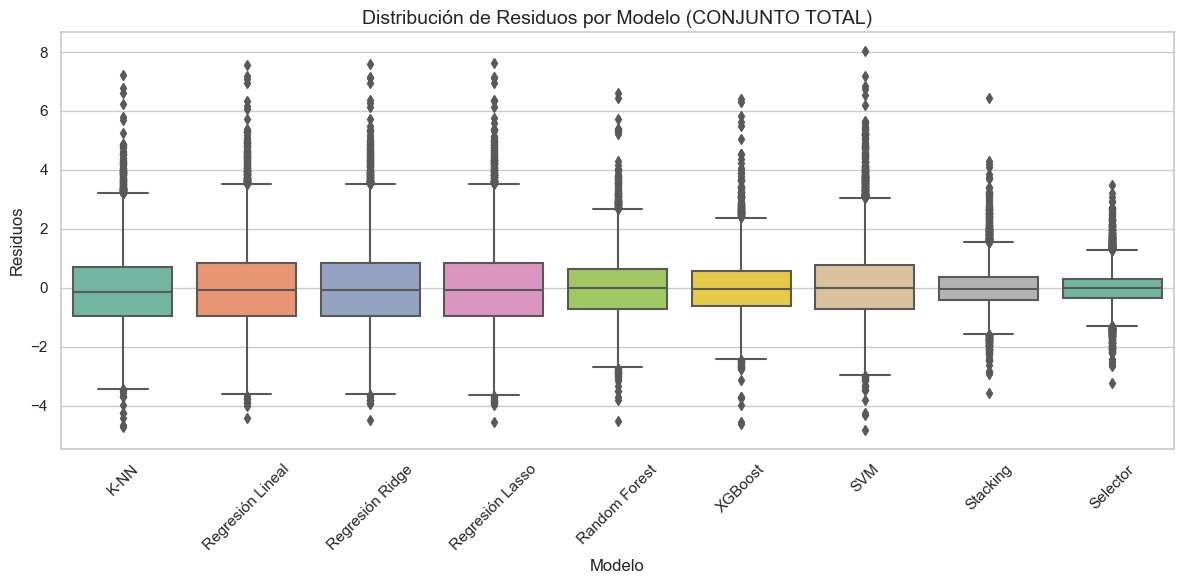

In [130]:
residuos_reales_largo = residuos_total.melt(var_name='Modelo', value_name='Residuos')
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.boxplot(x='Modelo', y='Residuos', data=residuos_reales_largo, palette="Set2")

plt.title('Distribución de Residuos por Modelo (CONJUNTO TOTAL)', fontsize=14)
plt.xlabel('Modelo')
plt.ylabel('Residuos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [131]:
mape_selector = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_final3) * 100

#MAE
mae_selector = mean_absolute_error(y_test, y_pred_final3)

#RMSE

rmse_selector = np.sqrt(mean_squared_error(y_test, y_pred_final3))

#R2

r2_selector= r2_score(y_test, y_pred_final3)  # R²

# Calcular Ljung-Box (test de autocorrelación de residuos)

residuos_selector = y_test - y_pred_final3
ljung_box_selector = acorr_ljungbox(residuos_selector, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value

# Calcular Jarque-Bera (test de normalidad de residuos)

jb_test_selector = jarque_bera(residuos_selector)
jarque_bera_selector = jb_test_selector.pvalue


tabla_resultados = pd.DataFrame({
    'Modelo': ['K-NN','Regresión Lineal','Regresión Ridge','Regresión Lasso','Random Forest','XGBoost','SVM','Stacking','Selector'],
    'MAE': [mae_knn, mae_regl, mae_ridge, mae_lasso, mae_rand, mae_xgb, mae_svm,mae_stacking,mae_selector],
    'RMSE': [rmse_knn, rmse_regl, rmse_ridge, rmse_lasso, rmse_rand, rmse_xgb, rmse_svm,rmse_stacking,rmse_selector],
    'R²': [r2_knn, r2_regl, r2_ridge, r2_lasso, r2_rand, r2_xgb, r2_svm,r2_stacking,r2_selector],
    'Ljung-Box p-value': [ljung_box_knn, ljung_box_regl, ljung_box_ridge, ljung_box_lasso, ljung_box_rand, ljung_box_xgb, ljung_box_svm,ljung_box_stacking,ljung_box_selector],
    'Jarque-Bera p-value': [jarque_bera_knn, jarque_bera_regl, jarque_bera_ridge, jarque_bera_lasso, jarque_bera_rand, jarque_bera_xgb, jarque_bera_svm,jarque_bera_stacking,jarque_bera_selector]
})

In [132]:
tabla_resultados

,Modelo,MAE,RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,K-NN,1.087727,1.380024,0.644261,0.278273,2.042609e-23
1,Regresión Lineal,1.091288,1.392489,0.637805,0.786225,5.794007e-38
2,Regresión Ridge,1.091540,1.393594,0.637230,0.845846,6.203846e-38
3,Regresión Lasso,1.092682,1.395503,0.636236,0.874495,9.424036e-38
4,Random Forest,0.889094,1.124339,0.763869,0.646184,7.348095e-23
5,XGBoost,0.770526,0.987792,0.817741,0.532367,7.159677e-46
6,SVM,0.998944,1.318057,0.675491,0.735189,1.105198e-89
7,Stacking,0.657735,0.865596,0.860045,0.944214,1.910119e-170
8,Selector,0.616460,0.793923,0.882262,0.972109,1.162681e-19
